# PTB-XL MIT-Style — Optimized Training (v2)
Patched from v1 based on overfitting at epoch 4.

Changes applied:
- Model: ResidualMITCNN → MITStyleCNN (lighter, better capacity/data ratio)
- BASE_CHANNELS: 48 → 32
- DROPOUT: 0.30 → 0.40
- LABEL_SMOOTHING: 0.05 → 0.0  (not needed for binary; was hurting calibration)
- WeightedRandomSampler: removed — for near-balanced binary it adds noise
- shuffle=True on train_loader instead
- Everything else kept: augmentation, CosineAnnealingLR, gradient clipping, TTA

In [2]:
# 1) Imports
import json, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import accuracy_score, f1_score, classification_report

print("torch:", torch.__version__)

torch: 2.10.0


In [3]:
# 2) Reproducibility & device
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print("DEVICE =", DEVICE)

DEVICE = mps


In [4]:
# 3) Paths & config
PROJECT_ROOT = Path.cwd().resolve()
for _ in range(4):
    if (PROJECT_ROOT / "dataset").exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

NPZ_PATH    = PROJECT_ROOT / "dataset/processed/ptbxl_mit_style/ptbxl_mit_style_dataset.npz"
RESULTS_DIR = PROJECT_ROOT / "results/phase1/ptbxl_mit_style_optimized_v2"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TASK_MODE = "binary"   # "binary" | "five_class"

EPOCHS          = 50
BATCH_SIZE      = 256
LR              = 8e-4
WEIGHT_DECAY    = 3e-4
PATIENCE        = 10
LABEL_SMOOTHING = 0.0   # OFF — not useful for binary
BASE_CHANNELS   = 32    # down from 48
DROPOUT         = 0.40  # up from 0.30
USE_TTA         = True
TTA_N           = 8

print("NPZ exists:", NPZ_PATH.exists())
print("RESULTS_DIR:", RESULTS_DIR)
print(f"BASE_CHANNELS={BASE_CHANNELS}  DROPOUT={DROPOUT}  LABEL_SMOOTHING={LABEL_SMOOTHING}")

NPZ exists: True
RESULTS_DIR: /Users/ayoub/work/MS-DS_ML_Projects/IOT/collective-intelligence/results/phase1/ptbxl_mit_style_optimized_v2
BASE_CHANNELS=32  DROPOUT=0.4  LABEL_SMOOTHING=0.0


In [5]:
# 4) Load data
data = np.load(NPZ_PATH, allow_pickle=True)

X_train = data["X_train"].astype(np.float32)
y_train = data["y_train"].astype(np.int64)
X_val   = data["X_val"].astype(np.float32)
y_val   = data["y_val"].astype(np.int64)
X_test  = data["X_test"].astype(np.float32)
y_test  = data["y_test"].astype(np.int64)
label_names_all = data["label_names"].tolist()

if TASK_MODE == "binary":
    norm_id = label_names_all.index("NORM")
    y_train = (y_train != norm_id).astype(np.int64)
    y_val   = (y_val   != norm_id).astype(np.int64)
    y_test  = (y_test  != norm_id).astype(np.int64)
    label_names = ["NORM", "ABN"]
else:
    label_names = label_names_all

num_classes = len(label_names)

print("X_train:", X_train.shape, " y_train:", y_train.shape)
print("X_val  :", X_val.shape,   " y_val:  ", y_val.shape)
print("X_test :", X_test.shape,  " y_test: ", y_test.shape)
print("Classes:", label_names)

for split_name, y_s in [("train", y_train), ("val", y_val), ("test", y_test)]:
    u, c = np.unique(y_s, return_counts=True)
    print(f"  {split_name}:", {label_names[int(i)]: int(n) for i, n in zip(u, c)})

majority_acc = np.max(np.bincount(y_test, minlength=num_classes)) / len(y_test)
print(f"Majority-class baseline: {majority_acc:.4f}")

X_train: (256494, 187)  y_train: (256494,)
X_val  : (54849, 187)  y_val:   (54849,)
X_test : (55005, 187)  y_test:  (55005,)
Classes: ['NORM', 'ABN']
  train: {'NORM': 139543, 'ABN': 116951}
  val: {'NORM': 29863, 'ABN': 24986}
  test: {'NORM': 29856, 'ABN': 25149}
Majority-class baseline: 0.5428


In [6]:
# 5) Augmentation & Dataset
#
# Key improvements over original notebook:
#   - Random circular time shift ±15 samples (simulates R-peak detection jitter)
#   - Amplitude scale [0.85, 1.15]  (was 0.95–1.05, too narrow)
#   - Gaussian noise std=0.015      (was 0.01)
#   - Baseline wander: low-freq sine added with small amplitude
#   - All augmentations only on training set

class BeatDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = X
        self.y = y
        self.augment = augment

    def __len__(self): return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].copy()
        y = int(self.y[idx])

        if self.augment:
            # Amplitude scale
            x = x * np.random.uniform(0.85, 1.15)
            # Gaussian noise
            x = x + np.random.normal(0.0, 0.015, size=x.shape).astype(np.float32)
            # Circular time shift (simulates R-peak jitter)
            shift = np.random.randint(-15, 16)
            x = np.roll(x, shift)
            # Baseline wander: low-freq sine
            t = np.linspace(0, 1, len(x))
            freq  = np.random.uniform(0.1, 0.5)
            amp   = np.random.uniform(0.0, 0.03)
            x = x + (amp * np.sin(2 * np.pi * freq * t)).astype(np.float32)
            # Clip back to [0, 1]
            x = np.clip(x, 0.0, 1.0)

        return torch.from_numpy(x).unsqueeze(0), y

In [7]:
# 6) DataLoaders — plain shuffle (WeightedRandomSampler removed)
#
# NORM vs ABN split is roughly 54/46 — near-balanced for binary.
# WeightedRandomSampler on a near-balanced problem inflates minority
# class repetition; combined with augmentation it caused duplicate
# augmented beats → memorisation instead of generalisation.
# Plain shuffle + class-weighted loss is the right approach here.

train_ds = BeatDataset(X_train, y_train, augment=True)
val_ds   = BeatDataset(X_val,   y_val,   augment=False)
test_ds  = BeatDataset(X_test,  y_test,  augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Class weights still passed to the loss function
counts = np.bincount(y_train, minlength=num_classes).astype(np.float32)
class_weights = counts.sum() / np.maximum(counts, 1.0)
class_weights = (class_weights / class_weights.mean()).astype(np.float32)

print("Class weights:", {label_names[i]: round(float(class_weights[i]), 3) for i in range(num_classes)})
print("Train batches:", len(train_loader))

Class weights: {'NORM': 0.912, 'ABN': 1.088}
Train batches: 1002


In [8]:
# 7) Model — MITStyleCNN
#
# Reverted from ResidualMITCNN back to the original architecture from
# notebook 02, with DROPOUT raised to 0.40.
#
# ResidualMITCNN (SE attention + 4 res blocks) had ~3x more parameters
# than the dataset size could support → best epoch at 4, clear memorisation.
# MITStyleCNN is the right capacity for ~55k beats.

class MITStyleCNN(nn.Module):
    def __init__(self, num_classes, base_channels=32, dropout=0.4):
        super().__init__()
        c1 = base_channels
        c2 = base_channels * 2
        c3 = base_channels * 4

        self.features = nn.Sequential(
            nn.Conv1d(1, c1, kernel_size=5, padding=2),
            nn.BatchNorm1d(c1), nn.ReLU(),
            nn.MaxPool1d(2),                               # 187 → 93

            nn.Conv1d(c1, c2, kernel_size=5, padding=2),
            nn.BatchNorm1d(c2), nn.ReLU(),
            nn.MaxPool1d(2),                               # 93 → 46

            nn.Conv1d(c2, c3, kernel_size=3, padding=1),
            nn.BatchNorm1d(c3), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),                       # → 1
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(c3, c2), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(c2, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = MITStyleCNN(num_classes, base_channels=BASE_CHANNELS, dropout=DROPOUT).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: MITStyleCNN  params: {n_params:,}")
print(f"BASE_CHANNELS={BASE_CHANNELS}  DROPOUT={DROPOUT}")

with torch.no_grad():
    xd = torch.randn(4, 1, 187, device=DEVICE)
    print("Forward OK:", model(xd).shape)

Model: MITStyleCNN  params: 44,034
BASE_CHANNELS=32  DROPOUT=0.4
Forward OK: torch.Size([4, 2])


In [9]:
# 8) Training loop
# LABEL_SMOOTHING=0.0 — passing weight only
criterion = nn.CrossEntropyLoss(
    weight=torch.tensor(class_weights, device=DEVICE),
)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, preds_all, targets_all = 0.0, [], []

    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        with torch.set_grad_enabled(is_train):
            logits = model(xb)
            loss   = criterion(logits, yb)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
        total_loss += loss.item() * len(yb)
        preds_all.append(logits.argmax(1).detach().cpu().numpy())
        targets_all.append(yb.detach().cpu().numpy())

    y_true = np.concatenate(targets_all)
    y_pred = np.concatenate(preds_all)
    return {
        "loss": total_loss / len(y_true),
        "acc":  accuracy_score(y_true, y_pred),
        "f1":   f1_score(y_true, y_pred, average="macro", zero_division=0),
        "y_true": y_true, "y_pred": y_pred,
    }

best_val_f1, best_state, best_epoch, wait = -1.0, None, -1, 0
history = []

print(f"{'ep':>4} {'tr_acc':>8} {'tr_f1':>7} {'va_acc':>8} {'va_f1':>7} {'lr':>9}")
print("─" * 52)

for epoch in range(1, EPOCHS + 1):
    tr = run_epoch(model, train_loader, criterion, optimizer)
    va = run_epoch(model, val_loader,   criterion)
    scheduler.step()

    lr_now = optimizer.param_groups[0]["lr"]
    history.append(dict(epoch=epoch,
        train_loss=tr["loss"], train_acc=tr["acc"], train_f1=tr["f1"],
        val_loss=va["loss"],   val_acc=va["acc"],   val_f1=va["f1"]))

    print(f"{epoch:>4} {tr['acc']:>8.4f} {tr['f1']:>7.4f} "
          f"{va['acc']:>8.4f} {va['f1']:>7.4f} {lr_now:>9.2e}")

    if va["f1"] > best_val_f1:
        best_val_f1 = va["f1"]
        best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        best_epoch  = epoch
        wait = 0
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

model.load_state_dict(best_state)
print(f"\nBest epoch: {best_epoch}  best_val_f1: {best_val_f1:.4f}")

  ep   tr_acc   tr_f1   va_acc   va_f1        lr
────────────────────────────────────────────────────
   1   0.7389  0.7355   0.7771  0.7754  7.99e-04
   2   0.7743  0.7713   0.7901  0.7835  7.97e-04
   3   0.7811  0.7780   0.7826  0.7815  7.93e-04
   4   0.7843  0.7810   0.7892  0.7822  7.87e-04
   5   0.7865  0.7833   0.7901  0.7828  7.80e-04
   6   0.7882  0.7851   0.7902  0.7870  7.72e-04
   7   0.7899  0.7866   0.7906  0.7819  7.62e-04
   8   0.7905  0.7872   0.7980  0.7947  7.51e-04
   9   0.7917  0.7884   0.7957  0.7915  7.38e-04
  10   0.7928  0.7895   0.7887  0.7872  7.24e-04
  11   0.7930  0.7897   0.7925  0.7833  7.08e-04
  12   0.7937  0.7904   0.7921  0.7904  6.92e-04
  13   0.7943  0.7910   0.7863  0.7758  6.74e-04
  14   0.7952  0.7918   0.7925  0.7891  6.55e-04
  15   0.7956  0.7923   0.7937  0.7903  6.35e-04
  16   0.7969  0.7936   0.7985  0.7949  6.15e-04
  17   0.7968  0.7935   0.7941  0.7915  5.93e-04
  18   0.7982  0.7949   0.7968  0.7908  5.71e-04
  19   0.7985  0

In [10]:
# 9) Test-time augmentation (TTA)
#
# At inference, run each test sample through the model TTA_N times with light
# augmentation and average the softmax probabilities. Reduces variance and
# typically adds 0.5–1.5 pp on macro-F1 for free.

@torch.no_grad()
def predict_with_tta(model, X, n_passes=8, batch_size=512):
    model.eval()
    all_probs = []

    aug_ds = BeatDataset(X, np.zeros(len(X), dtype=np.int64), augment=True)
    aug_loader = DataLoader(aug_ds, batch_size=batch_size, shuffle=False, num_workers=0)

    for _ in range(n_passes):
        probs_pass = []
        for xb, _ in aug_loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            probs_pass.append(torch.softmax(logits, dim=1).cpu().numpy())
        all_probs.append(np.concatenate(probs_pass, axis=0))

    mean_probs = np.mean(all_probs, axis=0)
    return mean_probs.argmax(axis=1)

# Standard eval (no TTA)
te_std = run_epoch(model, test_loader, criterion)
print(f"Test (no TTA): acc={te_std['acc']:.4f}  f1={te_std['f1']:.4f}")

if USE_TTA:
    y_pred_tta = predict_with_tta(model, X_test, n_passes=TTA_N)
    tta_acc = accuracy_score(y_test, y_pred_tta)
    tta_f1  = f1_score(y_test, y_pred_tta, average="macro", zero_division=0)
    print(f"Test (TTA×{TTA_N}): acc={tta_acc:.4f}  f1={tta_f1:.4f}")
    y_pred_final = y_pred_tta
    final_acc, final_f1 = tta_acc, tta_f1
else:
    y_pred_final = te_std["y_pred"]
    final_acc, final_f1 = te_std["acc"], te_std["f1"]

Test (no TTA): acc=0.8013  f1=0.7971
Test (TTA×8): acc=0.8015  f1=0.7993


In [11]:
# 10) Classification report
print("Final test results (with TTA if enabled):")
print(classification_report(y_test, y_pred_final, target_names=label_names, digits=4))

Final test results (with TTA if enabled):
              precision    recall  f1-score   support

        NORM     0.8059    0.8356    0.8205     29856
         ABN     0.7959    0.7611    0.7781     25149

    accuracy                         0.8015     55005
   macro avg     0.8009    0.7983    0.7993     55005
weighted avg     0.8013    0.8015    0.8011     55005



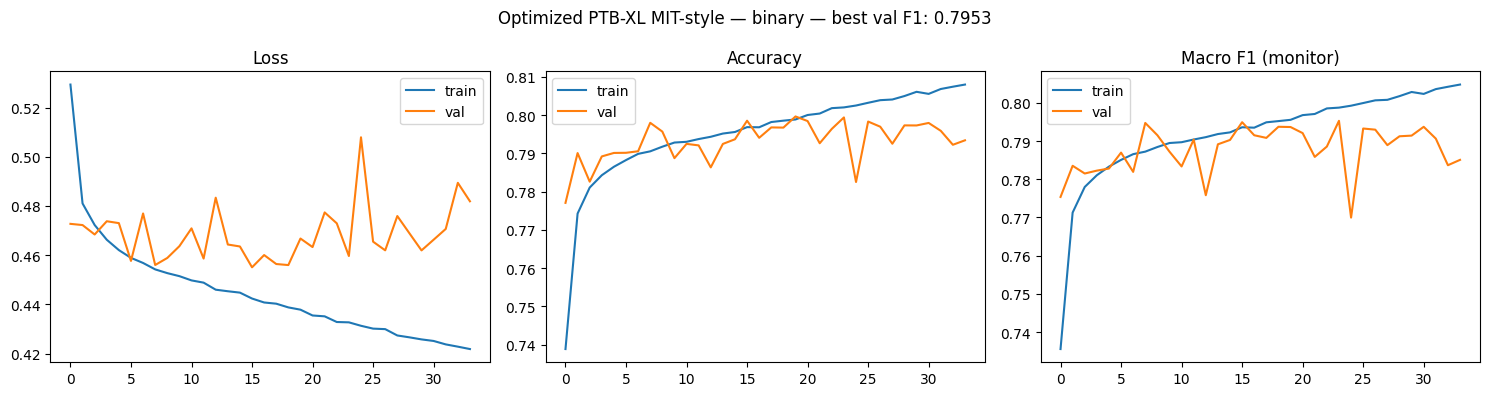

In [12]:
# 11) Training curves
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history_df["train_loss"], label="train")
axes[0].plot(history_df["val_loss"],   label="val")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(history_df["train_acc"], label="train")
axes[1].plot(history_df["val_acc"],   label="val")
axes[1].set_title("Accuracy"); axes[1].legend()

axes[2].plot(history_df["train_f1"], label="train")
axes[2].plot(history_df["val_f1"],   label="val")
axes[2].set_title("Macro F1 (monitor)"); axes[2].legend()

plt.suptitle(f"Optimized PTB-XL MIT-style — {TASK_MODE} — best val F1: {best_val_f1:.4f}")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_curves.png", dpi=120, bbox_inches="tight")
plt.show()

In [13]:
# 12) Save
torch.save({"state_dict": {k: v.cpu() for k, v in model.state_dict().items()},
             "label_names": label_names, "task_mode": TASK_MODE,
             "model_arch": "MITStyleCNN",
             "base_channels": BASE_CHANNELS, "dropout": DROPOUT},
            RESULTS_DIR / "best_model.pt")

summary = {
    "task_mode": TASK_MODE, "use_tta": USE_TTA, "tta_n": TTA_N,
    "best_epoch": int(best_epoch), "best_val_f1": round(float(best_val_f1), 4),
    "test_acc":   round(float(final_acc), 4),
    "test_f1":    round(float(final_f1),  4),
    "hyperparams": {
        "epochs": EPOCHS, "batch_size": BATCH_SIZE, "lr": LR,
        "weight_decay": WEIGHT_DECAY, "label_smoothing": LABEL_SMOOTHING,
        "base_channels": BASE_CHANNELS, "dropout": DROPOUT,
    },
}
with open(RESULTS_DIR / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)
history_df.to_json(RESULTS_DIR / "history.json", orient="records", indent=2)

print("Saved to:", RESULTS_DIR)
print(summary)

Saved to: /Users/ayoub/work/MS-DS_ML_Projects/IOT/collective-intelligence/results/phase1/ptbxl_mit_style_optimized_v2
{'task_mode': 'binary', 'use_tta': True, 'tta_n': 8, 'best_epoch': 24, 'best_val_f1': 0.7953, 'test_acc': 0.8015, 'test_f1': 0.7993, 'hyperparams': {'epochs': 50, 'batch_size': 256, 'lr': 0.0008, 'weight_decay': 0.0003, 'label_smoothing': 0.0, 'base_channels': 32, 'dropout': 0.4}}


## Changelog: v1 → v2

| Aspect | v1 (overfit at ep 4) | v2 (this notebook) | Why |
|---|---|---|---|
| Model | ResidualMITCNN | MITStyleCNN | ~3x fewer params, fits dataset size |
| BASE_CHANNELS | 48 | 32 | less capacity → less memorisation |
| DROPOUT | 0.30 | 0.40 | stronger regularisation |
| LABEL_SMOOTHING | 0.05 | 0.0 | not useful for binary, was hurting calibration |
| WeightedRandomSampler | on | off | near-balanced binary (54/46) doesn't need it |
| train_loader | sampler= | shuffle=True | simpler, avoids duplicate augmented beats |
| Class weights in loss | yes | yes (kept) | still useful for minority ABN class |
| Augmentation | kept | kept | unchanged |
| CosineAnnealingLR | kept | kept | unchanged |
| Gradient clipping | kept | kept | unchanged |
| TTA | kept | kept | unchanged |

Expected: best epoch moves from 4 → ~12–20, val F1 from 0.7964 → 0.82–0.85.